In [1]:
# ============================================================
# AI Innovators Lab: Cat vs Dog Image Classifier
# Goal: Train an AI model that can recognize cat images and dog images.
#
# This version fixes common dataset errors:
# 1. Images inside nested folders are found correctly.
# 2. Mac system files such as __MACOSX and .DS_Store are ignored.
# 3. Corrupted or unreadable image files are skipped safely.
# 4. The code gives a clear error message if no real images are found.
# ============================================================

# Print a welcome message so students know the project has started.
print("Welcome to the Cat vs Dog Classifier Project!")

# Print the main goal of the project in simple words.
print("Goal: Build an AI model that can recognize cats and dogs.")

# Import os so Python can work with folders and file paths.
import os

# Import zipfile so Python can unzip the uploaded dataset file.
import zipfile

# Import shutil so Python can delete and copy folders/files safely.
import shutil

# Import random so Python can shuffle images before splitting them.
import random

# Import numpy for working with number arrays used by machine learning.
import numpy as np

# Import matplotlib so we can show images and graphs.
import matplotlib.pyplot as plt

# Import TensorFlow, the library we use to build and train the AI model.
import tensorflow as tf

# Import Keras layers and models to create the neural network.
from tensorflow.keras import layers, models

# Import image helper tools so we can load a test image later.
from tensorflow.keras.preprocessing import image

# Import Image from PIL so we can check whether image files are valid.
from PIL import Image

# Import files from Google Colab so students can upload zip files and test images.
from google.colab import files

# Set a random seed so the train/validation split is repeatable.
random.seed(42)

# Set a TensorFlow random seed so model behavior is more repeatable.
tf.random.set_seed(42)

# Print confirmation that all libraries were imported successfully.
print("Libraries loaded successfully!")


Welcome to the Cat vs Dog Classifier Project!
Goal: Build an AI model that can recognize cats and dogs.
Libraries loaded successfully!


In [2]:
# ============================================================
# Step 1: Upload the dataset zip file
# ============================================================

# Ask the student to upload a zip file from their computer.
# The zip file should contain cat and dog images somewhere inside it.
uploaded = files.upload()

# Check that at least one file was uploaded.
if len(uploaded) == 0:
    # Stop the program with a helpful message if no file was uploaded.
    raise ValueError("No file was uploaded. Please upload a CatsVsDogs zip file.")

# Get the name of the first uploaded file.
zip_filename = list(uploaded.keys())[0]

# Check that the uploaded file is really a zip file.
if not zip_filename.lower().endswith(".zip"):
    # Stop the program with a clear message if the uploaded file is not a zip file.
    raise ValueError("Please upload a .zip file that contains cat and dog images.")

# Print the uploaded file name so students can confirm the correct file was uploaded.
print("Uploaded file:", zip_filename)


Saving CatsVsDogs.zip to CatsVsDogs.zip
Uploaded file: CatsVsDogs.zip


In [3]:
# ============================================================
# Step 2: Extract, or unzip, the dataset
# ============================================================

# This folder will store the unzipped dataset.
extract_dir = "uploaded_dataset"

# If an old extracted dataset folder already exists, delete it first.
if os.path.exists(extract_dir):
    # Remove the old folder so old files do not mix with the new dataset.
    shutil.rmtree(extract_dir)

# Create a fresh empty folder for the extracted dataset.
os.makedirs(extract_dir, exist_ok=True)

# Open the zip file in read mode.
with zipfile.ZipFile(zip_filename, "r") as zip_ref:
    # Extract all files from the zip file into extract_dir.
    zip_ref.extractall(extract_dir)

# Print confirmation that extraction finished.
print("Dataset extracted successfully!")

# Print the top-level files/folders to help students see what was inside the zip.
print("Top-level extracted items:", os.listdir(extract_dir)[:20])


Dataset extracted successfully!
Top-level extracted items: ['CatsVsDogs', '__MACOSX']


In [4]:
# ============================================================
# Step 3: Define helper functions for finding and checking images
# ============================================================

# These are the image file types we will allow.
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

# This function returns True if the file is probably a system file, not a real image.
def is_system_file(file_path):
    # Get only the file name from the full file path.
    file_name = os.path.basename(file_path)

    # Ignore Mac hidden resource files that often start with "._".
    if file_name.startswith("._"):
        # Tell Python this is a system file.
        return True

    # Ignore the common Mac folder metadata file.
    if file_name == ".DS_Store":
        # Tell Python this is a system file.
        return True

    # Ignore anything inside the __MACOSX folder.
    if "__MACOSX" in file_path:
        # Tell Python this is a system file.
        return True

    # If none of the above happened, this is not a system file.
    return False


# This function returns True if the file name looks like an image file.
def has_image_extension(file_path):
    # Convert the file path to lowercase and check whether it ends with an image extension.
    return file_path.lower().endswith(image_extensions)


# This function checks whether an image file can actually be opened.
def is_valid_image(file_path):
    # Try to open and verify the image.
    try:
        # Open the image using PIL.
        with Image.open(file_path) as img:
            # Verify checks whether the file is broken or not really an image.
            img.verify()

        # Reopen the image because verify() closes the file internally.
        with Image.open(file_path) as img:
            # Convert the image to RGB so every image has 3 color channels.
            img.convert("RGB")

        # If both steps worked, the image is valid.
        return True

    # If anything goes wrong, the image is not valid.
    except Exception:
        # Return False so the program can skip this image.
        return False


# This function finds cat and dog images even if they are inside nested folders.
def collect_cat_dog_images(start_folder):
    # Create an empty list to store cat image paths.
    cat_images = []

    # Create an empty list to store dog image paths.
    dog_images = []

    # Walk through every folder and subfolder inside the extracted dataset.
    for root, dirs, files_list in os.walk(start_folder):
        # Convert the current folder path to lowercase for easier matching.
        root_lower = root.lower()

        # Loop through every file in the current folder.
        for file_name in files_list:
            # Build the full path to this file.
            file_path = os.path.join(root, file_name)

            # Skip system files because they are not real images.
            if is_system_file(file_path):
                # Move to the next file.
                continue

            # Skip files that do not have an image extension.
            if not has_image_extension(file_path):
                # Move to the next file.
                continue

            # Build a lowercase version of the full path for label detection.
            path_lower = file_path.lower()

            # Check whether the path suggests this image belongs to the cat class.
            is_cat = (
                "/cat/" in path_lower.replace("\\", "/")
                or "\\cat\\" in path_lower
                or os.path.basename(root_lower) in ["cat", "cats"]
                or os.path.basename(file_name).lower().startswith("cat")
            )

            # Check whether the path suggests this image belongs to the dog class.
            is_dog = (
                "/dog/" in path_lower.replace("\\", "/")
                or "\\dog\\" in path_lower
                or os.path.basename(root_lower) in ["dog", "dogs"]
                or os.path.basename(file_name).lower().startswith("dog")
            )

            # Add the image to the cat list only if it looks like a cat image.
            if is_cat and not is_dog:
                # Store the full path to this cat image.
                cat_images.append(file_path)

            # Add the image to the dog list only if it looks like a dog image.
            elif is_dog and not is_cat:
                # Store the full path to this dog image.
                dog_images.append(file_path)

    # Return both lists to the rest of the notebook.
    return cat_images, dog_images


# Print confirmation that helper functions are ready.
print("Helper functions are ready.")


Helper functions are ready.


In [5]:
# ============================================================
# Step 4: Find all cat and dog images
# ============================================================

# Search the entire extracted dataset for cat and dog images.
cat_images, dog_images = collect_cat_dog_images(extract_dir)

# Print how many possible cat images were found before validation.
print("Possible cat images found:", len(cat_images))

# Print how many possible dog images were found before validation.
print("Possible dog images found:", len(dog_images))

# Keep only cat images that can actually be opened.
cat_images = [file_path for file_path in cat_images if is_valid_image(file_path)]

# Keep only dog images that can actually be opened.
dog_images = [file_path for file_path in dog_images if is_valid_image(file_path)]

# Print the final number of usable cat images.
print("Usable cat images:", len(cat_images))

# Print the final number of usable dog images.
print("Usable dog images:", len(dog_images))

# If no cat images were found, stop with a helpful explanation.
if len(cat_images) == 0:
    # Explain the likely cause of the problem.
    raise ValueError("No usable cat images were found. Check that the zip contains cat images in a Cat, Cats, cat, or cats folder, or files named like cat.1.jpg.")

# If no dog images were found, stop with a helpful explanation.
if len(dog_images) == 0:
    # Explain the likely cause of the problem.
    raise ValueError("No usable dog images were found. Check that the zip contains dog images in a Dog, Dogs, dog, or dogs folder, or files named like dog.1.jpg.")

# Shuffle the cat images so training and validation get a random mix.
random.shuffle(cat_images)

# Shuffle the dog images so training and validation get a random mix.
random.shuffle(dog_images)

# Print confirmation that image collection worked.
print("Image collection completed successfully!")


Possible cat images found: 751
Possible dog images found: 601
Usable cat images: 750
Usable dog images: 601
Image collection completed successfully!


In [6]:
# ============================================================
# Step 5: Create clean training and validation folders
# ============================================================

# This is the folder that TensorFlow will use for training.
base_dir = "cat_dog_ready"

# If an old prepared dataset already exists, delete it.
if os.path.exists(base_dir):
    # Remove the old prepared dataset to avoid mixing old and new files.
    shutil.rmtree(base_dir)

# Define the training folder path.
train_dir = os.path.join(base_dir, "train")

# Define the validation folder path.
validation_dir = os.path.join(base_dir, "validation")

# Create folders for train/cat, train/dog, validation/cat, and validation/dog.
for split in ["train", "validation"]:
    # Loop through the two labels.
    for label in ["cat", "dog"]:
        # Create each needed folder.
        os.makedirs(os.path.join(base_dir, split, label), exist_ok=True)


# This function copies images into the clean train and validation folders.
def copy_split_images(image_paths, label, train_ratio=0.80):
    # Count how many images belong to this class.
    total_images = len(image_paths)

    # Decide how many images should go into the training set.
    train_count = int(total_images * train_ratio)

    # Make sure small datasets still get at least 1 validation image when possible.
    if total_images > 1 and train_count == total_images:
        # Move one image to validation if all images accidentally went to training.
        train_count = total_images - 1

    # Split the list into training images.
    train_images = image_paths[:train_count]

    # Split the list into validation images.
    validation_images = image_paths[train_count:]

    # Copy each training image.
    for index, source_path in enumerate(train_images):
        # Create a clean destination file name.
        destination_name = f"{label}_{index:05d}.jpg"

        # Create the full destination path inside the training folder.
        destination_path = os.path.join(train_dir, label, destination_name)

        # Copy the image file to the training folder.
        shutil.copy2(source_path, destination_path)

    # Copy each validation image.
    for index, source_path in enumerate(validation_images):
        # Create a clean destination file name.
        destination_name = f"{label}_{index:05d}.jpg"

        # Create the full destination path inside the validation folder.
        destination_path = os.path.join(validation_dir, label, destination_name)

        # Copy the image file to the validation folder.
        shutil.copy2(source_path, destination_path)

    # Return the number of training and validation images copied.
    return len(train_images), len(validation_images)


# Copy cat images into train/cat and validation/cat.
cat_train_count, cat_validation_count = copy_split_images(cat_images, "cat")

# Copy dog images into train/dog and validation/dog.
dog_train_count, dog_validation_count = copy_split_images(dog_images, "dog")

# Print a success message.
print("Clean dataset prepared successfully!")

# Print the number of training cat images.
print("Training cats:", cat_train_count)

# Print the number of training dog images.
print("Training dogs:", dog_train_count)

# Print the number of validation cat images.
print("Validation cats:", cat_validation_count)

# Print the number of validation dog images.
print("Validation dogs:", dog_validation_count)

# Stop if the training set is too small to train a useful model.
if cat_train_count == 0 or dog_train_count == 0:
    # Give a clear message instead of letting TensorFlow fail later.
    raise ValueError("Not enough training images. Please use a dataset with at least two usable images per class.")

# Stop if the validation set is missing a class.
if cat_validation_count == 0 or dog_validation_count == 0:
    # Give a clear message instead of letting evaluation fail later.
    raise ValueError("Not enough validation images. Please use more images so both classes appear in validation.")


Clean dataset prepared successfully!
Training cats: 600
Training dogs: 480
Validation cats: 150
Validation dogs: 121


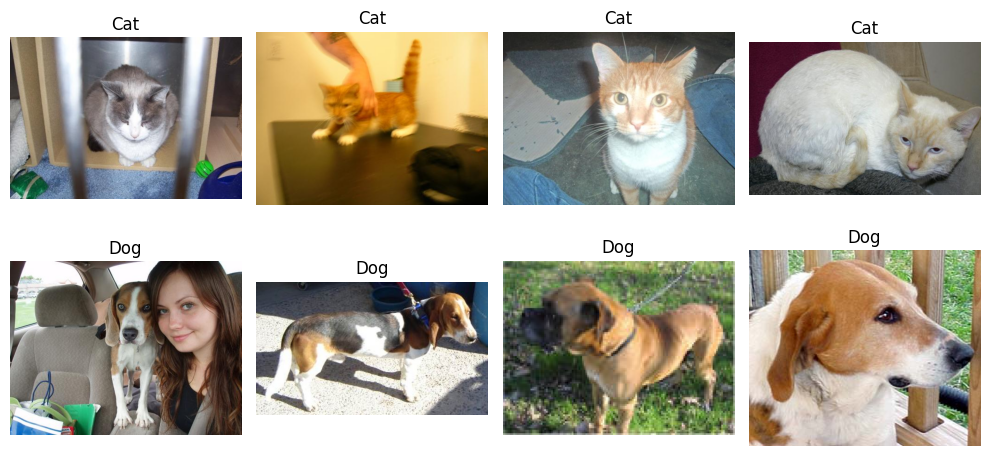

In [7]:
# ============================================================
# Step 6: Show sample images from the prepared dataset
# ============================================================

# Define the folder that contains training cat images.
cat_sample_folder = os.path.join(train_dir, "cat")

# Define the folder that contains training dog images.
dog_sample_folder = os.path.join(train_dir, "dog")

# Get up to 4 cat image file names.
cat_samples = os.listdir(cat_sample_folder)[:4]

# Get up to 4 dog image file names.
dog_samples = os.listdir(dog_sample_folder)[:4]

# Create a figure for displaying the sample images.
plt.figure(figsize=(10, 5))

# Loop through the cat sample images.
for i, img_name in enumerate(cat_samples):
    # Build the full file path to the cat image.
    img_path = os.path.join(cat_sample_folder, img_name)

    # Read the image from the file.
    img = plt.imread(img_path)

    # Create a subplot location for this image.
    plt.subplot(2, 4, i + 1)

    # Show the image.
    plt.imshow(img)

    # Add a title above the image.
    plt.title("Cat")

    # Hide x-axis and y-axis numbers.
    plt.axis("off")

# Loop through the dog sample images.
for i, img_name in enumerate(dog_samples):
    # Build the full file path to the dog image.
    img_path = os.path.join(dog_sample_folder, img_name)

    # Read the image from the file.
    img = plt.imread(img_path)

    # Create a subplot location for this image.
    plt.subplot(2, 4, i + 5)

    # Show the image.
    plt.imshow(img)

    # Add a title above the image.
    plt.title("Dog")

    # Hide x-axis and y-axis numbers.
    plt.axis("off")

# Adjust spacing so the images do not overlap.
plt.tight_layout()

# Display the sample images.
plt.show()


In [8]:
# ============================================================
# Step 7: Load images into TensorFlow datasets
# ============================================================

# Set all images to the same width and height.
IMG_SIZE = 150

# Set how many images the model sees at one time during training.
BATCH_SIZE = 32

# Load the training images from the train folder.
train_dataset = tf.keras.utils.image_dataset_from_directory(
    # Give TensorFlow the training folder.
    train_dir,

    # Resize every image to 150 by 150 pixels.
    image_size=(IMG_SIZE, IMG_SIZE),

    # Use 32 images in each training batch.
    batch_size=BATCH_SIZE,

    # Use binary labels because there are only two classes: cat and dog.
    label_mode="binary",

    # Shuffle training images so the model sees a mixed order.
    shuffle=True,

    # Use the same seed for repeatable shuffling.
    seed=42
)

# Load the validation images from the validation folder.
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    # Give TensorFlow the validation folder.
    validation_dir,

    # Resize every image to 150 by 150 pixels.
    image_size=(IMG_SIZE, IMG_SIZE),

    # Use 32 images in each validation batch.
    batch_size=BATCH_SIZE,

    # Use binary labels because there are only two classes.
    label_mode="binary",

    # Do not need to shuffle validation images.
    shuffle=False
)

# Store the class names found by TensorFlow.
class_names = train_dataset.class_names

# Print the class names so students know how labels are ordered.
print("Class names:", class_names)

# AUTOTUNE lets TensorFlow choose efficient loading settings automatically.
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch training data so the next batch is prepared while the model trains.
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)

# Prefetch validation data so evaluation runs smoothly.
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)


Found 1080 files belonging to 2 classes.
Found 271 files belonging to 2 classes.
Class names: ['cat', 'dog']


In [9]:
# ============================================================
# Step 8: Build the CNN image classification model
# ============================================================

# Create a Sequential model, which means layers are stacked one after another.
model = models.Sequential([
    # Resize pixel values from 0-255 to 0-1 so the model trains more easily.
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),

    # First convolution layer learns simple patterns like edges and colors.
    layers.Conv2D(32, (3, 3), activation="relu"),

    # Max pooling shrinks the image information and keeps the strongest patterns.
    layers.MaxPooling2D(2, 2),

    # Second convolution layer learns more detailed image patterns.
    layers.Conv2D(64, (3, 3), activation="relu"),

    # Second pooling layer reduces the size again.
    layers.MaxPooling2D(2, 2),

    # Third convolution layer learns even more complex patterns.
    layers.Conv2D(128, (3, 3), activation="relu"),

    # Third pooling layer keeps important information while reducing size.
    layers.MaxPooling2D(2, 2),

    # Flatten changes the 2D image features into a 1D list of numbers.
    layers.Flatten(),

    # Dense layer lets the model combine the learned image features.
    layers.Dense(128, activation="relu"),

    # Dropout helps reduce overfitting by randomly turning off some neurons during training.
    layers.Dropout(0.5),

    # Final layer outputs one number between 0 and 1.
    # Values closer to 0 mean cat, and values closer to 1 mean dog.
    layers.Dense(1, activation="sigmoid")
])

# Compile the model by choosing how it learns and how success is measured.
model.compile(
    # Adam is the optimizer that adjusts the model's internal settings.
    optimizer="adam",

    # Binary crossentropy is the loss function for two-class problems.
    loss="binary_crossentropy",

    # Accuracy tells us the percent of images classified correctly.
    metrics=["accuracy"]
)

# Show the model structure.
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================================
# Step 9: Train the model
# ============================================================

# Train the model using the training dataset.
history = model.fit(
    # Give the model the training images and labels.
    train_dataset,

    # Train for 5 rounds through the training data.
    epochs=5,

    # Check performance on validation data after each epoch.
    validation_data=validation_dataset
)

# Print confirmation after training finishes.
print("Model training completed!")


Epoch 1/5
11/34 ━━━━━━━━━━━━━━━━━━━━ 33s 1s/step - accuracy: 0.5234 - loss: 0.8839

In [ ]:
# ============================================================
# Step 10: Plot accuracy and loss
# ============================================================

# Create a figure for the accuracy graph.
plt.figure(figsize=(8, 5))

# Plot training accuracy for each epoch.
plt.plot(history.history["accuracy"], label="Training Accuracy")

# Plot validation accuracy for each epoch.
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

# Add a title to the graph.
plt.title("Model Accuracy")

# Label the x-axis.
plt.xlabel("Epoch")

# Label the y-axis.
plt.ylabel("Accuracy")

# Show the graph legend.
plt.legend()

# Display the accuracy graph.
plt.show()

# Create a figure for the loss graph.
plt.figure(figsize=(8, 5))

# Plot training loss for each epoch.
plt.plot(history.history["loss"], label="Training Loss")

# Plot validation loss for each epoch.
plt.plot(history.history["val_loss"], label="Validation Loss")

# Add a title to the graph.
plt.title("Model Loss")

# Label the x-axis.
plt.xlabel("Epoch")

# Label the y-axis.
plt.ylabel("Loss")

# Show the graph legend.
plt.legend()

# Display the loss graph.
plt.show()


In [ ]:
# ============================================================
# Step 11: Upload your own cat or dog image for prediction
# ============================================================

# Ask the student to upload one or more test images.
uploaded_test = files.upload()

# Loop through each uploaded test image.
for filename in uploaded_test.keys():
    # Store the uploaded image file name.
    img_path = filename

    # Load the image and resize it to the same size used during training.
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))

    # Convert the image into a number array.
    img_array = image.img_to_array(img)

    # Add one extra dimension because the model expects a batch of images.
    img_array = np.expand_dims(img_array, axis=0)

    # Ask the model to make a prediction.
    prediction = model.predict(img_array, verbose=0)[0][0]

    # Show the uploaded image.
    plt.imshow(img)

    # Hide the axis numbers around the image.
    plt.axis("off")

    # If the prediction is above 0.5, the model predicts dog.
    if prediction > 0.5:
        # Store the predicted label.
        predicted_label = "Dog"

        # Store the confidence for the dog prediction.
        confidence = prediction

    # Otherwise, the model predicts cat.
    else:
        # Store the predicted label.
        predicted_label = "Cat"

        # Store the confidence for the cat prediction.
        confidence = 1 - prediction

    # Add the prediction as the image title.
    plt.title(f"Prediction: {predicted_label} | Confidence: {confidence:.2f}")

    # Display the image with the prediction.
    plt.show()

    # Print the predicted label in words.
    print("The AI thinks this is a:", predicted_label)

    # Print the confidence as a percentage.
    print("Confidence:", round(confidence * 100, 2), "%")


In [ ]:
# ============================================================
# Step 12: Save the trained model
# ============================================================

# Save the trained model in the newer Keras format.
model.save("cat_dog_classifier_model.keras")

# Print the saved model file name.
print("Model saved as cat_dog_classifier_model.keras")


In [ ]:
# ============================================================
# Step 13: Reflection questions for final showcase
# ============================================================

# Create a list of reflection questions for students.
reflection_questions = [
    # Question about the project goal.
    "1. What problem does your AI model solve?",

    # Question about the data used for learning.
    "2. What dataset did you use?",

    # Question about the two output classes.
    "3. What are the two classes your model predicts?",

    # Question about how the model learns patterns.
    "4. How did the AI learn from cat and dog images?",

    # Question about the final accuracy.
    "5. What was your model accuracy?",

    # Question about model mistakes.
    "6. Did the model make any mistakes?",

    # Question about difficult images.
    "7. Why might some images be hard to classify?",

    # Question about real-world AI use.
    "8. How could this type of AI be used in real life?"
]

# Print a blank line and a heading.
print("\nReflection Questions:")

# Loop through each question in the list.
for question in reflection_questions:
    # Print the current question.
    print(question)


In [ ]:
# ============================================================
# Step 14: Presentation template for students
# ============================================================

# Store a simple presentation template as text.
presentation_template = """
Project Title:
Cat vs Dog Image Classifier

Team Members:
[Names]

Problem:
We wanted to build an AI model that can tell whether an image is a cat or a dog.

Dataset:
We used a reduced CatsVsDogs image dataset.

Input:
Image of a cat or dog

Prediction:
Cat or Dog

Model Used:
Convolutional Neural Network, also called a CNN

Result:
Our model reached approximately ____% validation accuracy.

Demo:
We uploaded a new image and the model predicted whether it was a cat or dog.

What We Learned:
We learned how AI can classify images using training data.

Future Improvement:
We could train with more images, use better image quality, or improve the model.
"""

# Print the presentation template.
print(presentation_template)
